# Entraîner son Propre Réseau de Neurones Pour la Reconnaissance Faciale

Préparé avec ❤️ par <a href="https://linkedin.com/in/dany-anderson-guimefack">Dany Anderson G.</a> et <a href="https://www.linkedin.com/in/ariste-yougbar%C3%A9-735387332/">Armel  Ariste Y.</a> <br>
Email📧: dany.guimefack@centrale-casablanca.ma // wendenkomarmelariste.yougbare2@centrale-casablanca.ma

Dans ce notebook, vous utiliserez les fonctions implémentées dans le notebook précédent pour construire un réseau de neurones profond et l'appliquer à une tâche de **reconnaissance faciale binaire** : *est la personne* (1) vs *n'est pas la personne* (0).

**À la fin de ce workshop, vous serez capable de :**

- Collecter votre propre jeu de données d'images via la webcam ou des photos déjà existantes
- Construire et entraîner un réseau de neurones profond à L couches sur ces images
- L'utiliser pour reconnaître un visage spécifique

**Note sur l'évaluateur automatique :** Ce notebook contient des cellules évaluées automatiquement. Évitez d'ajouter des `print` supplémentaires, de modifier les paramètres des fonctions, ou d'utiliser des variables globales dans les exercices.

Commençons !

## Table des matières
- [1 - Packages](#1)
- [2 - Collecte et chargement des données](#2)
 - [2.1 - Option A : capture par webcam](#2-1)
 - [2.2 - Option B : photos pré-sauvegardées](#2-2)
 - [2.3 - Chargement et prétraitement](#2-3)
- [3 - Architecture du modèle](#3)
 - [3.1 - Réseau de neurones à 2 couches](#3-1)
 - [3.2 - Réseau de neurones profond à L couches](#3-2)
 - [3.3 - Méthodologie générale](#3-3)
- [4 - Réseau de neurones à deux couches](#4)
 - [Exercice 1 - two_layer_model](#ex-1)
 - [4.1 - Entraîner le modèle](#4-1)
- [5 - Réseau de neurones à L couches](#5)
 - [Exercice 2 - L_layer_model](#ex-2)
 - [5.1 - Entraîner le modèle](#5-1)
- [6 - Analyse des résultats](#6)
- [7 - Testez avec votre propre image (exercice optionnel)](#7)

> **Note** : ce notebook est une version adaptée du devoir *Cat vs Non-Cat Classification* de la **Deep Learning Specialization** (DeepLearning.ai, Coursera). L'architecture et les fonctions auxiliaires viennent du cours original ; le pipeline de données a été modifié pour traiter une tâche de reconnaissance faciale au lieu de la classification chat / non-chat.

<a name='1'></a>
## 1 - Packages

Commencez par importer tous les packages dont vous aurez besoin dans ce notebook.

- [numpy](https://www.numpy.org/) est le package fondamental pour le calcul scientifique avec Python.
- [matplotlib](http://matplotlib.org) est une bibliothèque pour tracer des graphiques en Python.
- [PIL](http://www.pythonware.com/products/pil/) sert à charger et redimensionner les images.
- [opencv-python (cv2)](https://opencv.org/) capture les images depuis la webcam.
- [ipywidgets](https://ipywidgets.readthedocs.io/) affiche un aperçu en direct de la webcam dans le notebook.
- `dnn_app_utils_v3` fournit les fonctions implémentées dans le notebook précédent (`L_model_forward`, `predict`, etc.).
- `np.random.seed(1)` est utilisé pour assurer la reproductibilité des résultats. Ne le modifiez pas.

In [1]:
### v1.1

In [3]:
import time
import os
import uuid
import threading
import numpy as np
import matplotlib.pyplot as plt
import scipy
import cv2
import ipywidgets as widgets
from IPython.display import display as ipy_display
from PIL import Image
from scipy import ndimage
from dnn_app_utils_v3 import *
from public_tests import *

%matplotlib inline
plt.rcParams['figure.figsize'] = (5.0, 4.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

%load_ext autoreload
%autoreload 2

np.random.seed(1)

<a name='2'></a>
## 2 - Collecte et chargement des données

Au lieu d'un jeu de données pré-préparé, vous allez **construire le vôtre**. Le réseau apprendra une classification binaire :

- **classe 1 (`positive`)** : photos du visage cible (vous, ou la personne à reconnaître)
- **classe 0 (`negative`)** : photos d'autres personnes ou des arrière-plans variés

Les images sont stockées dans deux dossiers :

```
data/
  positive/   ← classe 1
  negative/   ← classe 0
```

**Recommandations :**
- Au moins 100–200 images par classe pour un résultat correct.
- Variez l'éclairage, l'angle, l'expression et l'arrière-plan.
- Gardez les images de taille raisonnable ; elles seront automatiquement redimensionnées en 64×64.

Vous avez deux moyens de remplir ces dossiers — choisissez l'un *ou* l'autre.

<a name='2-1'></a>
### 2.1 - Option A : capture par webcam

Le bloc ci-dessous prépare deux dossiers `data/positive/` et `data/negative/`. Si vous travaillez sans webcam, sautez à la **section 2.2**.

In [3]:
RAW_PATH = 'data'
CLASSES = ['positive', 'negative']
NUM_IMAGES = 60  # cible par classe

for cls in CLASSES:
    os.makedirs(os.path.join(RAW_PATH, cls), exist_ok=True)

print("Dossiers prêts :", os.listdir(RAW_PATH))

Dossiers prêts : ['negative', 'positive']


La fonction `capturer_images` ouvre la webcam dans le notebook et affiche un aperçu en direct accompagné de deux boutons :

- **📸 Sauvegarder** enregistre le cadre courant dans `data/<classe>/`.
- **❌ Quitter** ferme la caméra.

Adaptez `camera_index` selon votre matériel (`0` = webcam intégrée, parfois `1` ou `2` pour une caméra externe).

In [4]:
def capturer_images(cls, camera_index=2):
    """Capture des images depuis la webcam et les sauvegarde dans data/<cls>/."""
    cap = cv2.VideoCapture(camera_index)
    count = 0
    running = True
    last_frame = None

    img_widget = widgets.Image(format='jpeg', width=480)
    save_btn   = widgets.Button(description='📸 Sauvegarder', button_style='success')
    quit_btn   = widgets.Button(description='❌ Quitter',     button_style='danger')
    status     = widgets.Label(value=f"0/{NUM_IMAGES} sauvegardées — classe : {cls}")

    def on_save(b):
        nonlocal count, last_frame
        if last_frame is not None:
            path = os.path.join(RAW_PATH, cls, f"{cls}_{uuid.uuid1()}.jpg")
            cv2.imwrite(path, last_frame.copy())
            count += 1
            status.value = f"{count}/{NUM_IMAGES} sauvegardées — classe : {cls}"
            if count >= NUM_IMAGES:
                on_quit(None)

    def on_quit(b):
        nonlocal running
        running = False

    save_btn.on_click(on_save)
    quit_btn.on_click(on_quit)

    ipy_display(widgets.VBox([img_widget, widgets.HBox([save_btn, quit_btn]), status]))

    def apercu():
        nonlocal last_frame
        while running and cap.isOpened():
            ret, frame = cap.read()
            if not ret:
                break
            last_frame = frame
            annotated = frame.copy()
            cv2.putText(annotated, f"{cls}  {count}/{NUM_IMAGES}",
                        (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
            _, buf = cv2.imencode('.jpg', annotated)
            img_widget.value = buf.tobytes()
            time.sleep(0.05)

        cap.release()
        status.value = f"✅ Terminé — {count}/{NUM_IMAGES} sauvegardées pour '{cls}'"

    thread = threading.Thread(target=apercu, daemon=True)
    thread.start()
    return thread

**Capture des images positives** — placez-vous face à la caméra. Variez l'angle, l'expression, l'éclairage.

In [5]:
t = capturer_images('positive')

In [6]:
t.join()  # attendre la fin avant de passer à la classe suivante

**Capture des images négatives** — demandez à quelqu'un d'autre de se placer devant la caméra, ou filmez des arrière-plans variés.

In [7]:
t = capturer_images('negative')

In [ ]:
t.join()

<a name='2-2'></a>
### 2.2 - Option B : photos pré-sauvegardées

Si vous préférez ne pas utiliser la webcam, copiez simplement vos photos dans les dossiers correspondants :

```
data/
  positive/   ← vos photos du visage cible (.jpg, .jpeg ou .png)
  negative/   ← photos d'autres personnes ou d'arrière-plans
```

Quelques conseils :
- Recadrez les images autour du visage (à la main, ou avec un détecteur OpenCV / un outil en ligne).
- Les images n'ont pas besoin d'être carrées : `load_face_data` les redimensionne en 64×64.
- Visez 100–200 images par classe minimum.
- Mélangez les conditions (lumière, fond, expression) pour aider la généralisation.

<a name='2-3'></a>
### 2.3 - Chargement et prétraitement

La fonction `load_face_data` parcourt les deux dossiers, redimensionne chaque image en 64×64, mélange l'ensemble et le sépare en train / test.

In [4]:
def load_face_data(pos_dir='data/positive', neg_dir='data/negative', img_size=64, test_split=0.2, seed=1):
    """Charge un dataset binaire (positive=1, negative=0) depuis deux dossiers."""
    def load_dir(path, label):
        X, Y = [], []
        if not os.path.isdir(path):
            raise FileNotFoundError(f"Dossier introuvable : {path}")
        for f in sorted(os.listdir(path)):
            if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img = Image.open(os.path.join(path, f)).convert('RGB')
            img = img.resize((img_size, img_size))
            X.append(np.array(img))
            Y.append(label)
        return X, Y

    X1, Y1 = load_dir(pos_dir, 1)
    X0, Y0 = load_dir(neg_dir, 0)
    if len(X1) == 0 or len(X0) == 0:
        raise ValueError("Au moins un des deux dossiers est vide. Collectez des images avant d'entraîner.")

    X = np.array(X1 + X0)
    Y = np.array(Y1 + Y0)

    rng = np.random.default_rng(seed)
    idx = rng.permutation(len(Y))
    X, Y = X[idx], Y[idx]

    split = int(len(Y) * (1 - test_split))
    train_x_orig = X[:split]
    train_y      = Y[:split].reshape(1, -1)
    test_x_orig  = X[split:]
    test_y       = Y[split:].reshape(1, -1)
    return train_x_orig, train_y, test_x_orig, test_y

In [5]:
train_x_orig, train_y, test_x_orig, test_y = load_face_data(
    pos_dir='data/positive',
    neg_dir='data/negative',
    img_size=64,
)
classes = np.array([b'non-personne', b'personne'])  # pour compatibilité avec les utilitaires existants

Le code suivant affiche une image du jeu de données. Vous pouvez modifier l'index et relancer la cellule pour explorer d'autres images.

y = 1. C'est une image personne.


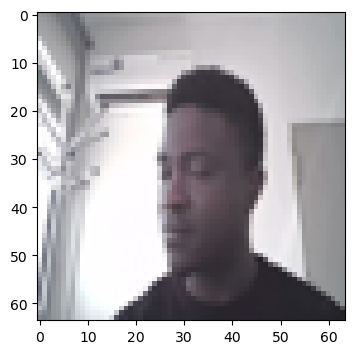

In [6]:
# Exemple d'image
index = 0
plt.imshow(train_x_orig[index])
print("y = " + str(train_y[0, index]) + ". C'est une image " + classes[train_y[0, index]].decode("utf-8") + ".")
plt.show()

In [7]:
# Explorer le jeu de données

m_train = train_x_orig.shape[0]
num_px = train_x_orig.shape[1]
m_test = test_x_orig.shape[0]

print("Nombre d'exemples d'entraînement : " + str(m_train))
print("Nombre d'exemples de test : " + str(m_test))
print("Chaque image est de taille : (" + str(num_px) + ", " + str(num_px) + ", 3)")
print("train_x_orig shape: " + str(train_x_orig.shape))
print("train_y shape: " + str(train_y.shape))
print("test_x_orig shape: " + str(test_x_orig.shape))
print("test_y shape: " + str(test_y.shape))

Nombre d'exemples d'entraînement : 129
Nombre d'exemples de test : 33
Chaque image est de taille : (64, 64, 3)
train_x_orig shape: (129, 64, 64, 3)
train_y shape: (1, 129)
test_x_orig shape: (33, 64, 64, 3)
test_y shape: (1, 33)


Comme d'habitude, vous redimensionnez et normalisez les images avant de les transmettre au réseau. Le code est donné dans la cellule ci-dessous.

<img src="images/imvectorkiank.png" style="width:450px;height:300px;">
<caption><center><font color='purple'><b>Figure 1</b> : Conversion d'une image en vecteur.</font></center></caption>

In [8]:
# Redimensionner les exemples d'entraînement et de test
train_x_flatten = train_x_orig.reshape(train_x_orig.shape[0], -1).T # Le "-1" dans reshape permet d'aplatir les dimensions restantes
test_x_flatten = test_x_orig.reshape(test_x_orig.shape[0], -1).T

# Normaliser les données pour avoir des valeurs entre 0 et 1.
train_x = train_x_flatten/255
test_x = test_x_flatten/255.


print ("train_x's shape: " + str(train_x.shape))
print ("test_x's shape: " + str(test_x.shape))

train_x's shape: (12288, 129)
test_x's shape: (12288, 33)


**Note**:
$12\,288$ est égal à $64 \times 64 \times 3$, qui correspond à la taille d'un vecteur image aplati.

<a name='3'></a>
## 3 - Architecture du modèle

<a name='3-1'></a>
### 3.1 - Réseau de neurones à 2 couches

Maintenant que vous êtes familiarisé avec le jeu de données, il est temps de construire un réseau de neurones profond pour distinguer les visages cibles des autres visages.

Vous allez construire deux modèles différents :

- Un réseau de neurones à 2 couches
- Un réseau de neurones profond à L couches

Puis, vous comparerez les performances de ces modèles, et essaierez différentes valeurs pour $L$. 
Regardons les deux architectures :

<img src="images/2layerNN_kiank.png" style="width:650px;height:400px;">
<caption><center><font color='purple'><b>Figure 2</b> : Réseau de neurones à 2 couches. <br> Le modèle peut être résumé ainsi : ENTRÉE -> LINÉAIRE -> RELU -> LINÉAIRE -> SIGMOÏDE -> SORTIE.</font></center></caption>

<u><b>Architecture détaillée de la Figure 2</b></u> :
- L'entrée est une image (64,64,3) aplatie en un vecteur de taille $(12288,1)$. - Le vecteur correspondant $[x_0,x_1,...,x_{12287}]^T$ est multiplié par la matrice de poids $W^{[1]}$ de taille $(n^{[1]}, 12288)$.
- Ensuite, on ajoute un biais et on applique ReLU pour obtenir le vecteur $[a_0^{[1]}, a_1^{[1]},..., a_{n^{[1]}-1}^{[1]}]^T$.
- On multiplie le vecteur résultant par $W^{[2]}$ et on ajoute le biais. - Enfin, on applique la sigmoïde au résultat. Si le résultat est supérieur à 0,5, classez-le comme la personne.

<a name='3-2'></a>
### 3.2 - Réseau de neurones profond à L couches

Il est assez difficile de représenter un réseau de neurones profond à L couches avec la représentation ci-dessus. Voici néanmoins une représentation simplifiée :

<img src="images/LlayerNN_kiank.png" style="width:650px;height:400px;">
<caption><center><font color='purple'><b>Figure 3</b> : Réseau de neurones à L couches. <br> Le modèle peut être résumé ainsi : [LINÉAIRE -> RELU] $\times$ (L-1) -> LINÉAIRE -> SIGMOÏDE</font></center></caption>

<u><b>Architecture détaillée de la Figure 3</b></u> :
- L'entrée est une image (64,64,3) aplatie en un vecteur de taille (12288,1).
- Le vecteur correspondant $[x_0,x_1,...,x_{12287}]^T$ est multiplié par la matrice de poids $W^{[1]}$, puis on ajoute le biais $b^{[1]}$. Le résultat est appelé l'unité linéaire.
- Ensuite, on applique ReLU à l'unité linéaire. Ce processus peut être répété plusieurs fois pour chaque $(W^{[l]}, b^{[l]})$ selon l'architecture du modèle.
- Enfin, on applique la sigmoïde à la dernière unité linéaire. Si le résultat est supérieur à 0,5, on classifie l'image comme la personne.

<a name='3-3'></a>
### 3.3 - Méthodologie générale

Comme d'habitude, vous suivrez la méthodologie de l'apprentissage profond pour construire le modèle :

1. Initialiser les paramètres / Définir les hyperparamètres
2. Boucle sur num_iterations :
    a. Propagation avant
    b. Calculer la fonction de coût
    c. Rétropropagation
    d. Mettre à jour les paramètres (en utilisant les paramètres et les gradients de la rétropropagation)
3. Utiliser les paramètres entraînés pour prédire les étiquettes

Vous pouvez maintenant implémenter ces deux modèles !

<a name='4'></a>
## 4 - Réseau de neurones à deux couches

<a name='ex-1'></a>
### Exercice 1 - two_layer_model 
Utilisez les fonctions auxiliaires du notebook précédent pour construire un réseau de neurones à 2 couches avec la structure suivante : *LINÉAIRE -> RELU -> LINÉAIRE -> SIGMOÏDE*. Les fonctions et leurs entrées sont :
```python
def initialize_parameters(n_x, n_h, n_y):
 ...
 return paramètres 
def linear_activation_forward(A_prev, W, b, activation):
 ...
 return A, cache
def compute_cost(AL, Y):
 ...
 return coût
def linear_activation_backward(dA, cache, activation):
 ...
 return dA_prev, dW, db
def update_parameters(paramètres, grads, learning_rate):
 ...
 return paramètres
```

In [9]:
### CONSTANTES DÉFINISSANT LE MODÈLE ####
n_x = 12288 # num_px * num_px * 3
n_h = 7
n_y = 1
layers_dims = n_x, n_h, n_y
learning_rate = 0.0075

In [18]:
# FONCTION : two_layer_model
def two_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=True):
    """
 Implémente un réseau de neurones à deux couches : LINÉAIRE->RELU->LINÉAIRE->SIGMOÏDE.
 
 Arguments :
 
 X -- données d'entrée, de forme (n_x, nombre d'exemples)
 Y -- vecteur d'étiquettes réelles (contenant 1 si la personne, 0 sinon), de forme (1, nombre d'exemples)
 layers_dims -- dimensions des couches (n_x, n_h, n_y)
 num_iterations -- nombre d'itérations de la boucle d'optimisation
 learning_rate -- taux d'apprentissage de la règle de mise à jour par descente de gradient
 print_cost -- Si True, affiche le coût toutes les 100 itérations
 
 Retourne :
 paramètres -- un dictionnaire contenant W1, W2, b1 et b2
 """
    
    np.random.seed(1)
    grads = {}
    costs = []                               # pour suivre l'évolution du coût
    m = X.shape[1]                           # nombre d'exemples
    n_x, n_h, n_y = layers_dims
    
    # Initialiser le dictionnaire des paramètres en appelant une fonction déjà implémentée 
    #(≈ 1 ligne de code) 
    # parameters = ... 
    # VOTRE CODE COMMENCE ICI 
    parameters = initialize_parameters(n_x, n_h, n_y)   
    # VOTRE CODE SE TERMINE ICI 
    # Extraire W1, b1, W2 et b2 du dictionnaire paramètres. 
    W1 = parameters["W1"]
    b1 = parameters["b1"]
    W2 = parameters["W2"]
    b2 = parameters["b2"]
 
    # Boucle (descente de gradient) 
    for i in range(0, num_iterations):
        # Propagation avant : LINÉAIRE -> RELU -> LINÉAIRE -> SIGMOÏDE. Entrées : "X, W1, b1, W2, b2". Sorties : "A1, cache1, A2, cache2". 
        #(≈ 2 lignes de code) 
        #A1, cache1 = forward_propagation(X,parameters)
        #A2, cache2 = forward_propagation(A1,parameters)
        # VOTRE CODE COMMENCE ICI 
        A1, cache1 = linear_activation_forward(X, W1, b1, activation="relu")
        A2, cache2 = linear_activation_forward(A1, W2, b2, activation="sigmoid")        
        
        # VOTRE CODE SE TERMINE ICI 
        
        # Calculer le coût #(≈ 1 ligne de code) 
        
        #cost = ...        
        # VOTRE CODE COMMENCE ICI 
        cost = compute_cost(A2, Y)        
        # VOTRE CODE SE TERMINE ICI 
        
        # Initialisation de la rétropropagation 

        dA2 = - (np.divide(Y, A2) - np.divide(1 - Y, 1 - A2))
        
        # Rétropropagation. Entrées : "dA2, cache2, cache1". Sorties : "dA1, dW2, db2 ; aussi dA0 (non utilisé), dW1, db1". 
        #(≈ 2 lignes de code) 
        # dA1, dW2, db2 = ... 
        # dA0, dW1, db1 = ... 
        # VOTRE CODE COMMENCE ICI 
        dA1, dW2, db2 = linear_activation_backward(dA2, cache2, activation="sigmoid") 
        dA0, dW1, db1 = linear_activation_backward(dA1, cache1, activation="relu")
        # VOTRE CODE SE TERMINE ICI 
        # Assigner grads['dW1'] à dW1, grads['db1'] à db1, grads['dW2'] à dW2, grads['db2'] à db2 
        grads['dW1'] = dW1 
        grads['db1'] = db1
        grads['dW2'] = dW2
        grads['db2'] = db2
        
        # Mettre à jour paramètres. 
        #(environ 1 ligne de code) 
        # parameters = ... 
        # VOTRE CODE COMMENCE ICI 
        parameters = update_parameters(parameters, grads, learning_rate)
        # VOTRE CODE SE TERMINE ICI 
        # Récupérer W1, b1, W2, b2 depuis paramètres 
        
        W1 = parameters["W1"] 
        b1 = parameters["b1"]
        W2 = parameters["W2"]
        b2 = parameters["b2"]
        
        # Afficher le coût toutes les 100 itérations 
        if print_cost and i % 100 == 0 or i == num_iterations - 1: 
            print("Coût après l'itération {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0 or i == num_iterations:
            costs.append(cost)
    return parameters, costs

def plot_costs(costs, learning_rate=0.0075):
    plt.plot(np.squeeze(costs))
    plt.ylabel('cost')
    plt.xlabel('itérations (par centaines)')
    plt.title("Taux d'apprentissage =" + str(learning_rate))
    plt.show()

In [19]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2, print_cost=False)

print("Cost after first iteration: " + str(costs[0]))

two_layer_model_test(two_layer_model)

Coût après l'itération 1: 0.6925821228356974
Cost after first iteration: 0.6928700046737891
Coût après l'itération 0: 0.6931596772639871
Coût après l'itération 1: 0.6915746967050506
Coût après l'itération 0: 0.6931596772639871
Coût après l'itération 1: 0.6915746967050506
Coût après l'itération 0: 0.6931596772639871
Coût après l'itération 1: 0.6915746967050506
Coût après l'itération 0: 0.6931596772639871
Coût après l'itération 2: 0.6524135179683452
 All tests passed.


**Sortie attendue :**
```
Le coût après l'itération 1 doit être environ 0.69
```

<a name='4-1'></a>
### 4.1 - Entraîner le modèle 
Si votre code a réussi la cellule précédente, exécutez la cellule ci-dessous pour entraîner vos paramètres. 
- Le coût devrait diminuer à chaque itération. 
- Cela peut prendre jusqu'à 5 minutes pour exécuter 2500 itérations.

Coût après l'itération 0: 0.6928700046737891
Coût après l'itération 100: 0.09623325743944039
Coût après l'itération 200: 0.01544473789272282
Coût après l'itération 300: 0.007163836332783192
Coût après l'itération 400: 0.0044529027346936565
Coût après l'itération 500: 0.003161200600281214
Coût après l'itération 600: 0.002420343177583503
Coût après l'itération 700: 0.0019454001149381741
Coût après l'itération 800: 0.0016174535295127215
Coût après l'itération 900: 0.0013786523688152775
Coût après l'itération 1000: 0.0011976946905972116
Coût après l'itération 1100: 0.0010562484296720099
Coût après l'itération 1200: 0.0009429096603675377
Coût après l'itération 1300: 0.000850229286381045
Coût après l'itération 1400: 0.0007731490701484483
Coût après l'itération 1500: 0.0007081184938530424
Coût après l'itération 1600: 0.0006525774511111192
Coût après l'itération 1700: 0.0006046341238985991
Coût après l'itération 1800: 0.0005628630499587408
Coût après l'itération 1900: 0.0005261700108149738
Coû

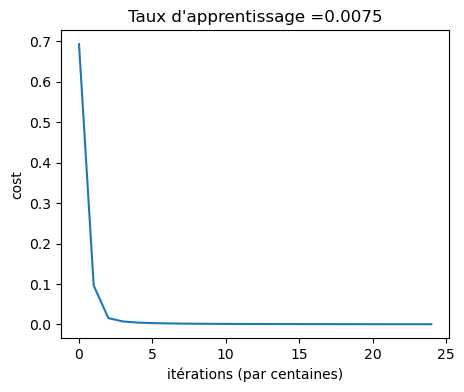

In [20]:
parameters, costs = two_layer_model(train_x, train_y, layers_dims = (n_x, n_h, n_y), num_iterations = 2500, print_cost=True)
plot_costs(costs, learning_rate)

**Sortie attendue :**
<table>  <tr>
 <td> <b>Coût après l'itération 0</b></td>
 <td> 0.6930497356599888 </td>
 </tr>
 <tr>
 <td> <b>Coût après l'itération 100</b></td>
 <td> 0.6464320953428849 </td>
 </tr>
 <tr>
 <td> <b>...</b></td>
 <td> ... </td>
 </tr>
 <tr>
 <td> <b>Coût après l'itération 2499</b></td>
 <td> 0.04421498215868956 </td>
 </tr>
</table>

**Bien joué !** Vous avez entraîné le modèle avec succès. Grâce à l'implémentation vectorisée, l'entraînement est bien plus rapide.

Vous pouvez maintenant utiliser les paramètres entraînés pour classer les images du jeu de données. Exécutez la cellule ci-dessous pour voir les prédictions sur les ensembles d'entraînement et de test.

In [21]:
predictions_train = predict(train_x, train_y, parameters)

Accuracy: 1.0


**Sortie attendue :**
<table>  <tr>
 <td> <b>Précision</b></td>
 <td> 0.9999999999999998 </td>
 </tr>
</table>

In [22]:
predictions_test = predict(test_x, test_y, parameters)

Accuracy: 1.0


**Sortie attendue :**
<table>  <tr>
 <td> <b>Précision</b></td>
 <td> 0.72 </td>
 </tr>
</table>

### Bien joué ! Il semble que votre réseau de neurones à 2 couches soit plus performant (72 %) que l'implémentation de régression logistique (70 %). Voyons si vous pouvez faire encore mieux avec un modèle à $L$ couches.

**Note** : Vous remarquerez peut-être qu'entraîner le modèle sur moins d'itérations (par exemple 1500) donne une meilleure précision sur l'ensemble de test. C'est ce qu'on appelle l'**arrêt précoce** (*early stopping*), une technique pour éviter le surapprentissage.

<a name='5'></a>
## 5 - Réseau de neurones profond à L couches

<a name='ex-2'></a>
### Exercice 2 - L_layer_model 
Utilisez les fonctions auxiliaires implémentées précédemment pour construire un réseau de neurones à $L$ couches avec la structure suivante : *[LINÉAIRE -> RELU]$\times$(L-1) -> LINÉAIRE -> SIGMOÏDE*. Les fonctions et leurs entrées sont :
```python
def initialize_parameters_deep(layers_dims):
 ...
 return paramètres 
def L_model_forward(X, paramètres):
 ...
 return AL, caches
def compute_cost(AL, Y):
 ...
 return coût
def L_model_backward(AL, Y, caches):
 ...
 return grads
def update_parameters(paramètres, grads, learning_rate):
 ...
 return paramètres
```

In [23]:
### CONSTANTS ###
layers_dims = [12288, 20, 7, 5, 1] # modèle à 4-couche

In [27]:
# FONCTION : L_layer_model
def L_layer_model(X, Y, layers_dims, learning_rate = 0.0075, num_iterations = 3000, print_cost=False):
    """
 Implémente un réseau de neurones à L couches : [LINÉAIRE->RELU]*(L-1)->LINÉAIRE->SIGMOÏDE.
 
 Arguments :
 X -- données d'entrée, de forme (n_x, nombre d'exemples)
 Y -- vecteur d'étiquettes réelles (contenant 1 si la personne, 0 sinon), de forme (1, nombre d'exemples)
 layers_dims -- liste contenant la taille d'entrée et la taille de chaque couche, de longueur (nombre de couches + 1).
 learning_rate -- taux d'apprentissage de la règle de mise à jour par descente de gradient
 num_iterations -- nombre d'itérations de la boucle d'optimisation
 print_cost -- si True, affiche le coût toutes les 100 étapes
 
 Retourne :
 paramètres -- paramètres appris par le modèle. Ils peuvent ensuite être utilisés pour prédire.
 """

    np.random.seed(1)
    costs = []                         # suivre l'évolution du coût
    
    # Initialisation des paramètres. 
    #(≈ 1 ligne de code) 
    # parameters = ... 
    # VOTRE CODE COMMENCE ICI 
    parameters = initialize_parameters_deep(layers_dims)    
    # VOTRE CODE SE TERMINE ICI 
    # Boucle (descente de gradient) 
    for i in range(0, num_iterations):# Propagation avant : [LINÉAIRE -> RELU]*(L-1) -> LINÉAIRE -> SIGMOÏDE. 
        #(≈ 1 ligne de code) 
        # AL, caches = ... 
        # VOTRE CODE COMMENCE ICI 

        AL, caches = L_model_forward(X, parameters)
        
        # VOTRE CODE SE TERMINE ICI 
        # Calculer le coût. 
        #(≈ 1 ligne de code) 
        # cost = ... 
        # VOTRE CODE COMMENCE ICI 
        cost = compute_cost(AL, Y)
        # VOTRE CODE SE TERMINE ICI 
        # Rétropropagation. 
        #(≈ 1 ligne de code) 
        # grads = ... 
        # VOTRE CODE COMMENCE ICI 

        grads = L_model_backward(AL, Y, caches)
        
        # VOTRE CODE SE TERMINE ICI 
        # Mettre à jour paramètres. 
        #(≈ 1 ligne de code) 
        # parameters = ... 
        # VOTRE CODE COMMENCE ICI 
        parameters = update_parameters(parameters, grads, learning_rate)
        # VOTRE CODE SE TERMINE ICI 
        # Afficher le coût toutes les 100 itérations 
        if print_cost and i % 100 == 0 or i == num_iterations - 1: 
            print("Coût après l'itération {}: {}".format(i, np.squeeze(cost)))
        if i % 100 == 0 or i == num_iterations:
            costs.append(cost)
    
    return parameters, costs

In [28]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 1, print_cost = False)

print("Cost after first iteration: " + str(costs[0]))

L_layer_model_test(L_layer_model)

Coût après l'itération 0: 0.7193620896443688
Cost after first iteration: 0.7193620896443688
Coût après l'itération 1: 0.7070709008912569
Coût après l'itération 1: 0.7070709008912569
Coût après l'itération 1: 0.7070709008912569
Coût après l'itération 2: 0.7063462654190897
 All tests passed.


<a name='5-1'></a>
### 5.1 - Entraîner le modèle 
Si votre code a réussi la cellule précédente, exécutez la cellule ci-dessous pour entraîner votre modèle en tant que réseau de neurones à 4 couches. 
- Le coût devrait diminuer à chaque itération. 
- Cela peut prendre jusqu'à 5 minutes pour exécuter 2500 itérations.

In [30]:
parameters, costs = L_layer_model(train_x, train_y, layers_dims, num_iterations = 2500, print_cost = True)

Coût après l'itération 0: 0.7193620896443688
Coût après l'itération 100: 0.29259742871798616
Coût après l'itération 200: 0.2541450811051982
Coût après l'itération 300: 0.2228198351219064
Coût après l'itération 400: 0.19656310930046136
Coût après l'itération 500: 0.17415726872846954
Coût après l'itération 600: 0.15491647467901942
Coût après l'itération 700: 0.1383535841036343
Coût après l'itération 800: 0.1239536870163506
Coût après l'itération 900: 0.11137839167524509
Coût après l'itération 1000: 0.10037820335109147
Coût après l'itération 1100: 0.09072198435732612
Coût après l'itération 1200: 0.08220515238451383
Coût après l'itération 1300: 0.07470446358068286
Coût après l'itération 1400: 0.06806796526037776
Coût après l'itération 1500: 0.06221288680493627
Coût après l'itération 1600: 0.05709261875937396
Coût après l'itération 1700: 0.052435010828908786
Coût après l'itération 1800: 0.04833795626374172
Coût après l'itération 1900: 0.04464442544738008
Coût après l'itération 2000: 0.04129

**Sortie attendue :**
<table>  <tr>
 <td> <b>Coût après l'itération 0</b></td>
 <td> 0.771749 </td>
 </tr>
 <tr>
 <td> <b>Coût après l'itération 100</b></td>
 <td> 0.672053 </td>
 </tr>
 <tr>
 <td> <b>...</b></td>
 <td> ... </td>
 </tr>
 <tr>
 <td> <b>Coût après l'itération 2499</b></td>
 <td> 0.088439 </td>
 </tr>
</table>

In [31]:
pred_train = predict(train_x, train_y, parameters)

Accuracy: 1.0


**Sortie attendue :**
<table>
 <tr>
 <td>
 <b>Précision entraînement</b>
 </td>
 <td>
 0.985645933014
 </td>
 </tr>
</table>

In [33]:
pred_test = predict(test_x, test_y, parameters)

Accuracy: 1.0


**Sortie attendue :**
<table>  <tr>
 <td> <b>Précision sur l'ensemble de test</b></td>
 <td> 0.8 </td>
 </tr>
</table>

### Félicitations ! Il semble que votre réseau à 4 couches soit plus performant (80 %) que votre réseau à 2 couches (72 %) sur le même ensemble de test.

C'est une très bonne performance pour cette tâche. Excellent travail !

<a name='6'></a>
## 6 - Analyse des résultats

Commencez par observer des images mal classées par le modèle à L couches. Cela montre quelques exemples d'erreurs.

In [35]:
print_mislabeled_images(classes, test_x, test_y, pred_test)

**Quelques types d'images que le modèle a tendance à mal classer :**
- Visage dans une pose inhabituelle (de profil, partiellement masqué)
- Visage sur un fond très différent de ceux du jeu d'entraînement
- Conditions d'éclairage inhabituelles
- Angle ou distance par rapport à la caméra non représentés dans les données
- Variation d'échelle (visage très grand ou très petit dans l'image)

### Félicitations !

Vous venez de construire et d'entraîner un réseau de neurones profond à L couches, et de l'appliquer pour reconnaître un visage spécifique.

Si vous le souhaitez, vous pouvez tester votre modèle avec votre propre image dans l'exercice optionnel ci-dessous.

<a name='7'></a>
## 7 - Testez avec votre propre image (exercice optionnel)

Pour tester le modèle avec une image qui ne fait pas partie du jeu d'entraînement :

1. Ajoutez votre image dans le dossier `images/` de ce répertoire (créez-le si besoin).
2. Modifiez le nom de l'image dans le code ci-dessous.
3. Exécutez la cellule et vérifiez la prédiction (1 = c'est la personne, 0 = ce n'est pas la personne).

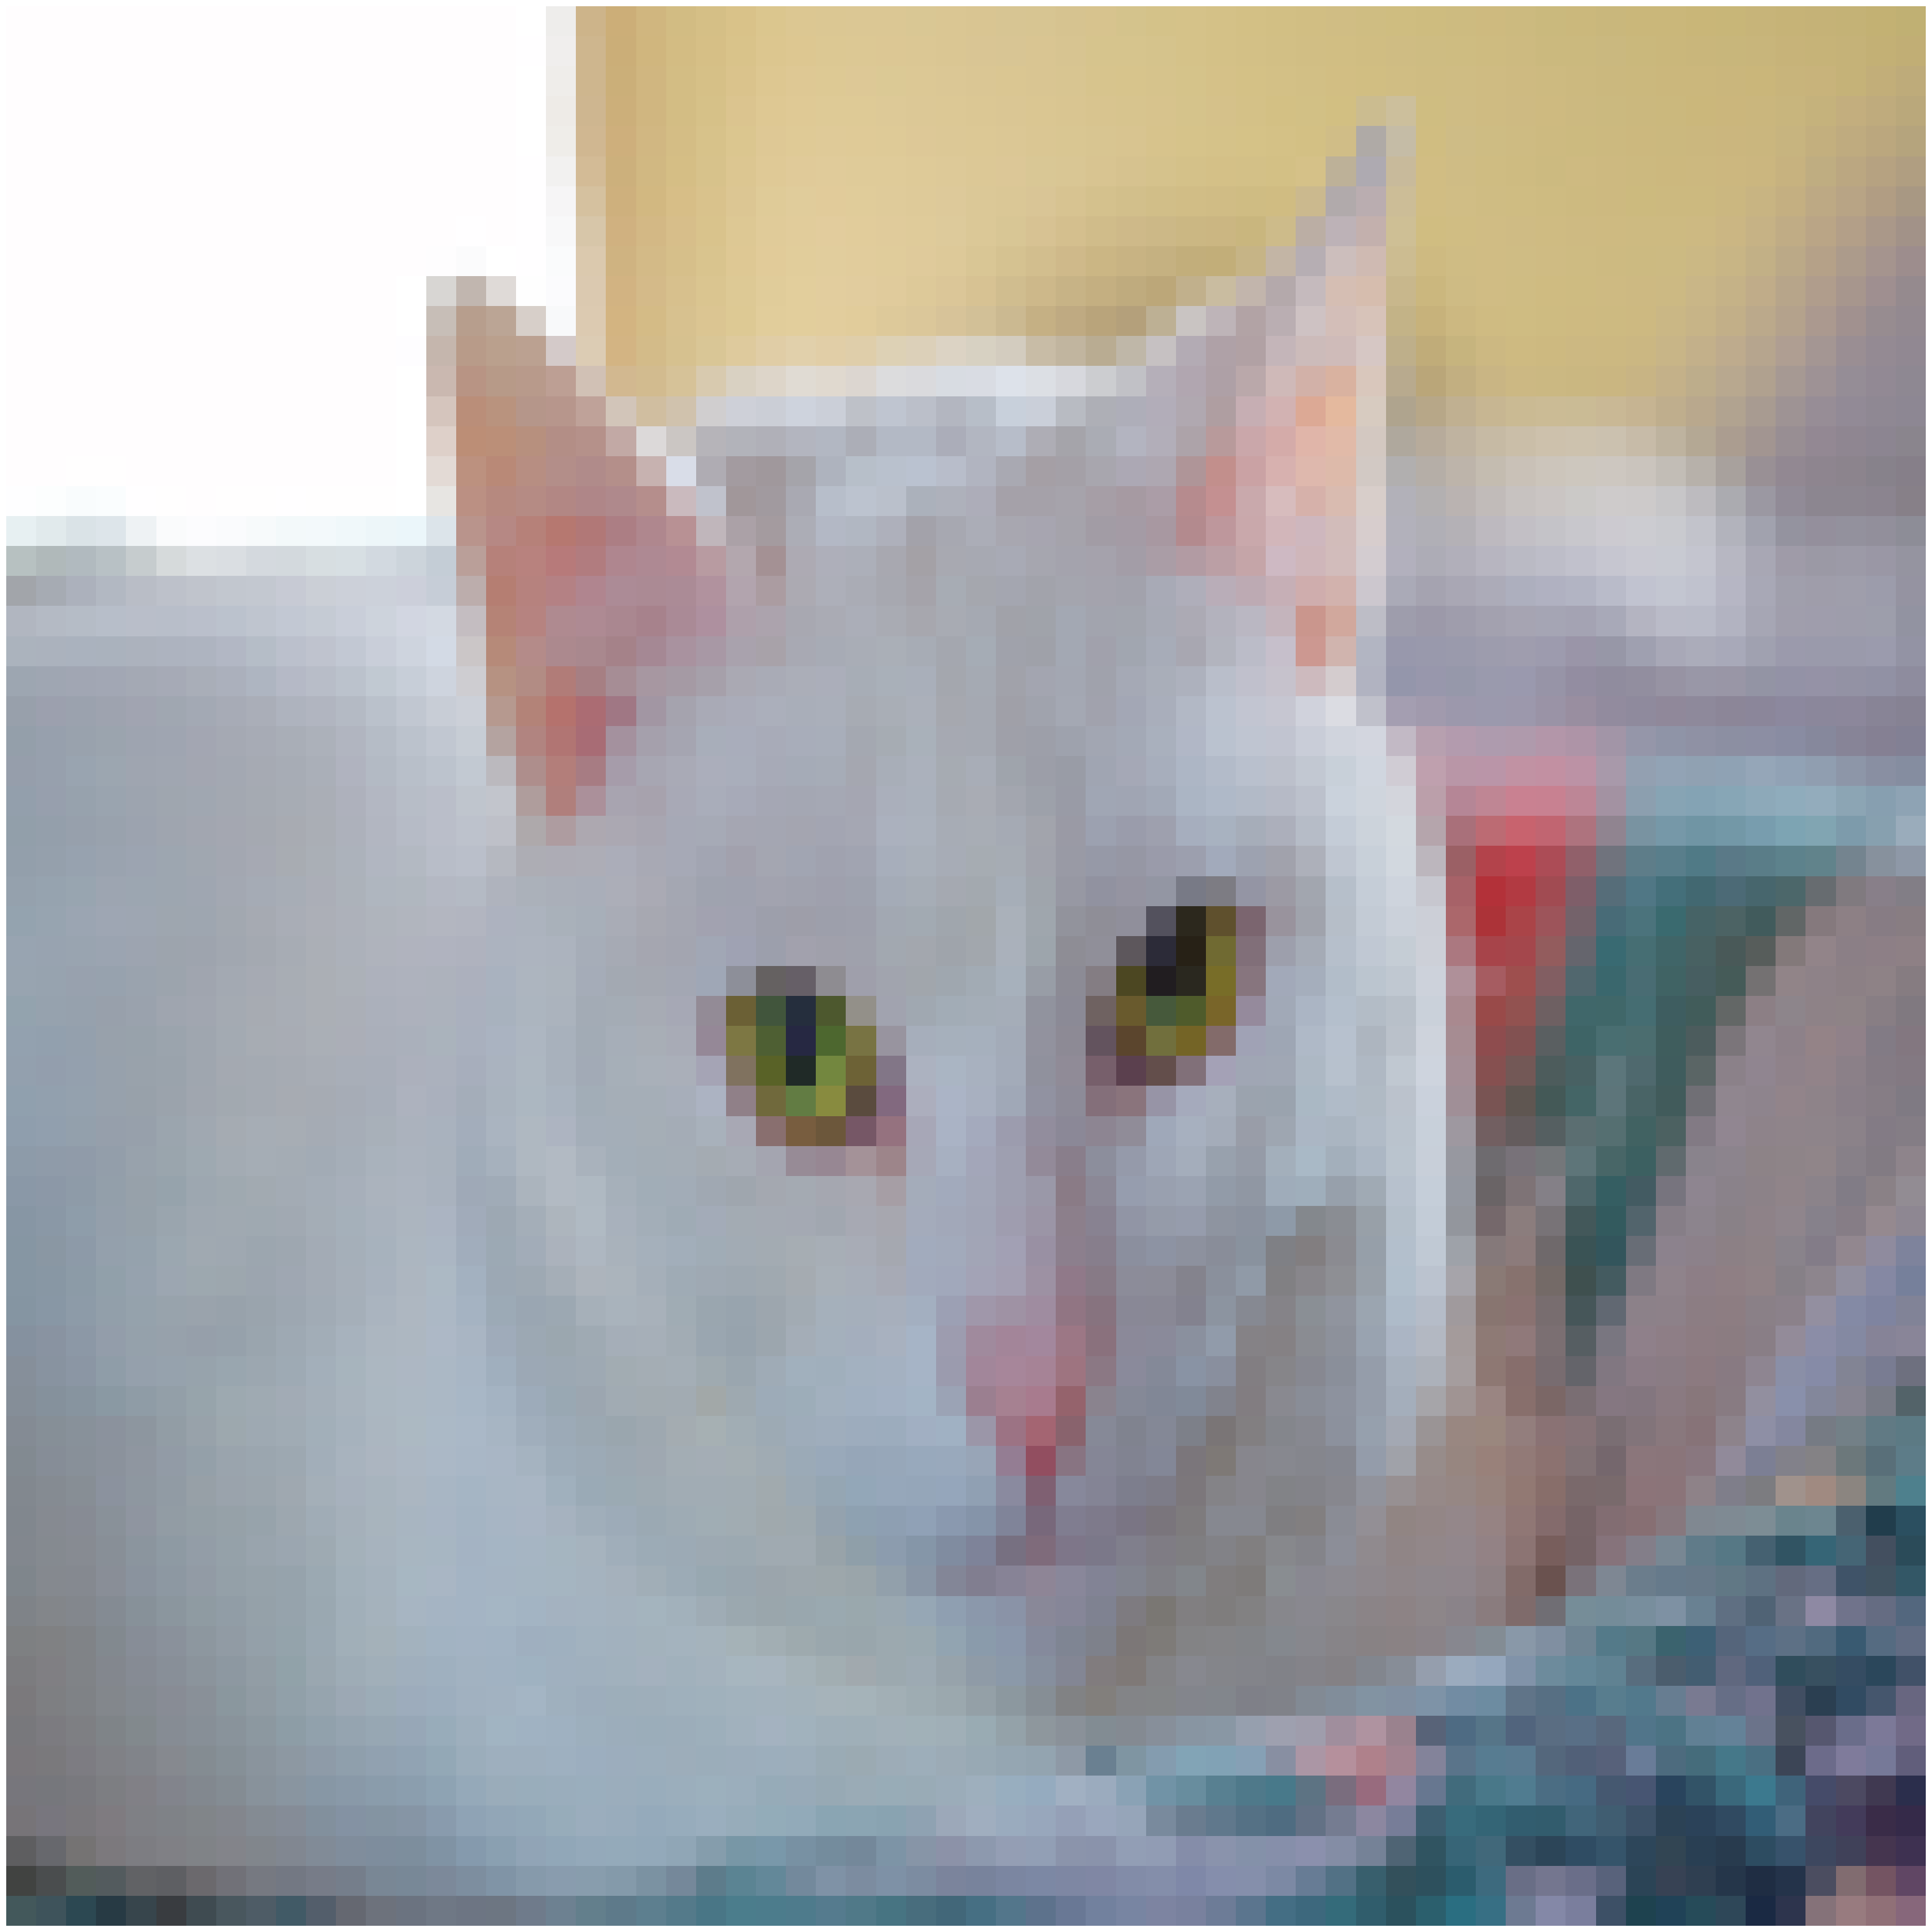

Accuracy: 1.0
y = 1 — votre modèle prédit que c'est la personne.


In [36]:
## DÉBUT DU CODE ##
my_image = "my_image.jpg"   # nom de votre fichier dans le dossier images/
my_label_y = [1]             # 1 si c'est la personne, 0 sinon
## FIN DU CODE ##

fname = "images/" + my_image
image = np.array(Image.open(fname).convert('RGB').resize((num_px, num_px)))
plt.imshow(image)
plt.axis('off')
plt.show()

x = image.reshape((1, num_px * num_px * 3)).T / 255.
my_predicted_image = predict(x, my_label_y, parameters)
pred = int(np.squeeze(my_predicted_image))
label = "c'est la personne" if pred == 1 else "ce n'est pas la personne"
print(f"y = {pred} — votre modèle prédit que {label}.")

**Références** :

- *Deep Learning Specialization* — DeepLearning.ai sur Coursera (devoir original *Cat vs Non-Cat Classification* dont ce notebook est une adaptation)
